PHASE 4 MACHINE LEARNING MODELING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import(
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
sns.set_theme(style="darkgrid")

In [3]:
df = pd.read_csv('kepler_clean.csv')
TARGET = 'koi_disposition'

FileNotFoundError: [Errno 2] No such file or directory: 'kepler_clean.csv'

In [ ]:
df_model = df[df[TARGET].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
print(f"Rowws for modeling: {len(df_model):,}")
print(df_model[TARGET].value_counts())

KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_score', 'koi_depth',
    'koi_duration', 'koi_impact',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]

X = df_model[KEY_FEATURES]
y_raw = df_model[TARGET]

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"\nLabel EncodingP: {dict(zip(le.classes_, le.transform(le.classes_)))}")

#Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

# HANDLE CLASS IMBALANCE WITH SMOTE
print(f"\nBefore SMOTE — class counts in training set:")
print(pd.Series(y_train).value_counts())

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)
print(f"\nAfter SMOTE — class counts in training set:")
print(pd.Series(y_train_bal).value_counts())

Rowws for modeling: 6,203
koi_disposition
FALSE POSITIVE    3922
CONFIRMED         2281
Name: count, dtype: int64

Label EncodingP: {'CONFIRMED': np.int64(0), 'FALSE POSITIVE': np.int64(1)}

Train size: 4,962
Test size: 1,241

Before SMOTE — class counts in training set:
1    3137
0    1825
Name: count, dtype: int64

After SMOTE — class counts in training set:
1    3137
0    3137
Name: count, dtype: int64


SCALE FEATURES & TRAIN MODELS

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test_imp)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

results = {}
print("\n" + "=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

for name, model in models.items():
    print(f"\n── {name} ──")

    # Train (Random Forest & XGBoost don't need scaling,
    # but using scaled data works fine for tree models too)
    if name == 'SVM':
        model.fit(X_train_scaled, y_train_bal)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]

    # Metrics
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1':     f1,
        'auc':    auc
    }

    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}" if auc else "ROC-AUC  : N/A")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


MODEL TRAINING & EVALUATION

── Random Forest ──
F1 Score : 0.9943
ROC-AUC  : 0.9989

Classification Report:
                precision    recall  f1-score   support

     CONFIRMED       1.00      0.98      0.99       456
FALSE POSITIVE       0.99      1.00      0.99       785

      accuracy                           0.99      1241
     macro avg       0.99      0.99      0.99      1241
  weighted avg       0.99      0.99      0.99      1241


── XGBoost ──
F1 Score : 0.9930
ROC-AUC  : 0.9981

Classification Report:
                precision    recall  f1-score   support

     CONFIRMED       1.00      0.98      0.99       456
FALSE POSITIVE       0.99      1.00      0.99       785

      accuracy                           0.99      1241
     macro avg       0.99      0.99      0.99      1241
  weighted avg       0.99      0.99      0.99      1241


── Gradient Boosting ──
F1 Score : 0.9924
ROC-AUC  : 0.9974

Classification Report:
                precision    recall  f1-score   supp

CONFUSION MATRIX - ALL MODELS

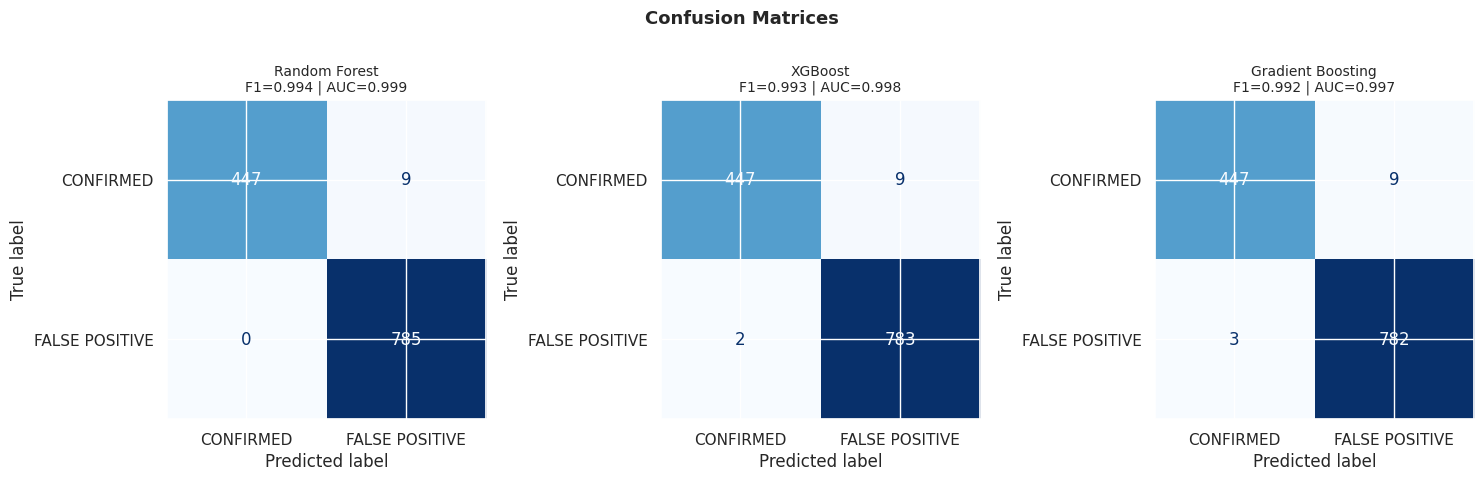

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))

for ax, (name, res) in zip(axes, results.items()):
  cm = confusion_matrix(y_test, res['y_pred'])
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
  disp.plot(ax=ax, colorbar=False, cmap='Blues')
  ax.set_title(f'{name}\nF1={res["f1"]:.3f} | AUC={res["auc"]:.3f}', fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

ROC CURVE - ALL MODELS

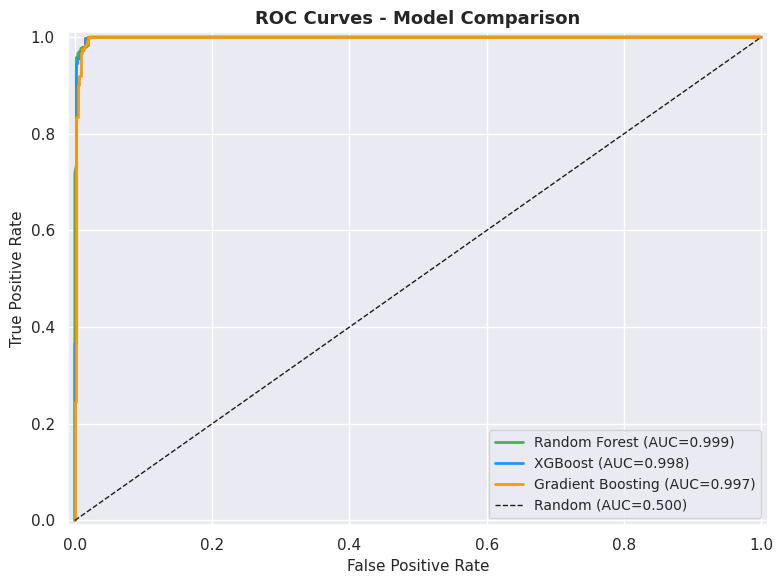

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

colors_roc = ['#4CAF50', '#2196F3', '#FF9800']

for (name, res), color in zip(results.items(), colors_roc):
  if res['y_prob'] is not None:
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})',
            color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('p4_roc_curves.png', dpi=150)
plt.show()

FEATURE IMPORTANCE - RANDOM FOREST & XGBOOST

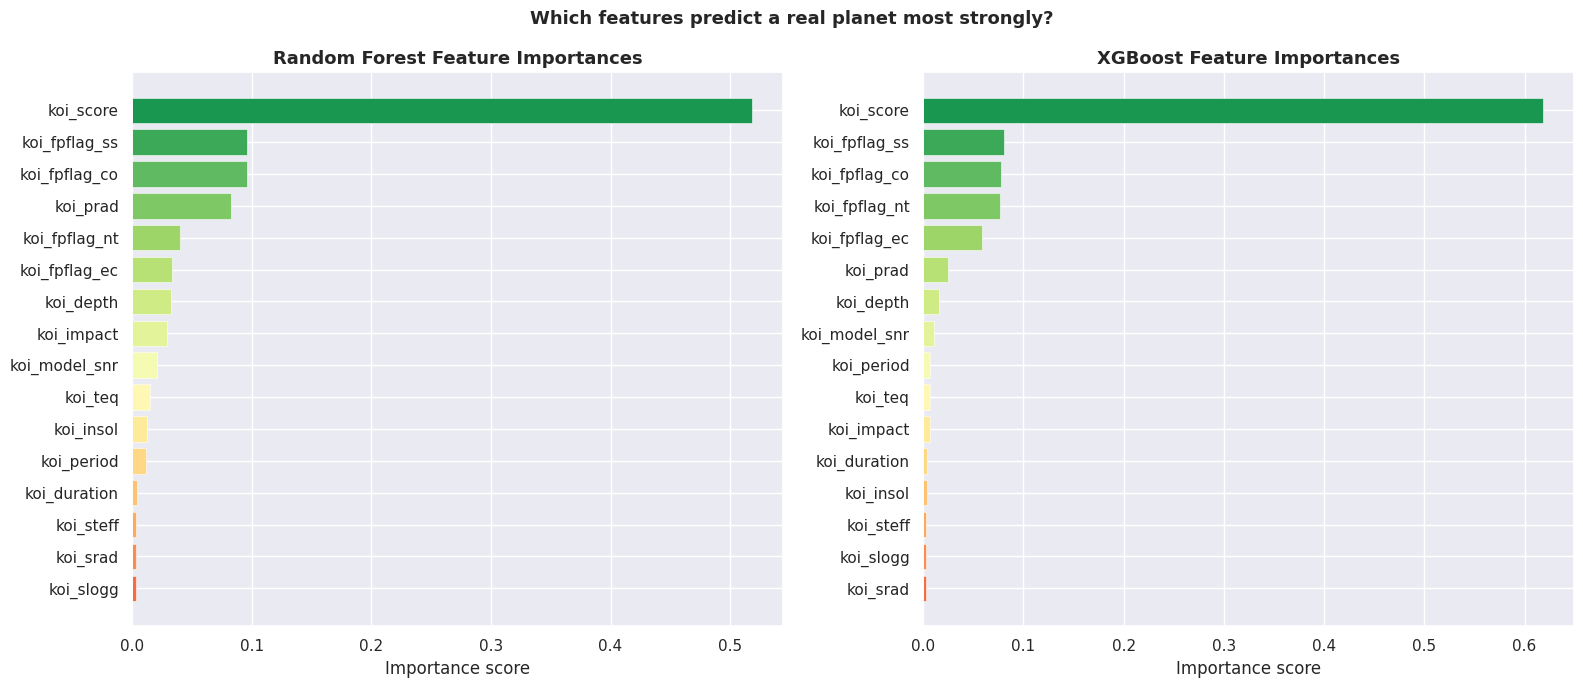

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
  model = results[model_name]['model']
  importances = model.feature_importances_
  feat_imp = pd.DataFrame({
      'Feature': KEY_FEATURES,
      'Importance': importances
  }).sort_values('Importance', ascending = True)

  colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
  ax.barh(feat_imp['Feature'], feat_imp['Importance'],
          color = colors, edgecolor = 'white', linewidth = 0.4)
  ax.set_title(f'{model_name} Feature Importances', fontsize = 13, fontweight = 'bold')
  ax.set_xlabel('Importance score') # Corrected from ax.set_label

plt.suptitle('Which features predict a real planet most strongly?',
              fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig('p4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

CROSS-VALIDATION - ROBUST EVALUATION

In [ ]:
print("\n---5-fold Cross Validation (RANDOM FOREST) ----")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = results['Random Forest']['model']
cv_scores = cross_val_score(rf, X_train_bal, y_train_bal,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC per fold : {cv_scores.round(4)}")
print(f"Mean AUC : {cv_scores.mean():.4f} ± {cv_scores.std():4f}")


---5-fold Cross Validation (RANDOM FOREST) ----
AUC per fold : [0.9991 0.9998 0.9995 0.9996 0.9999]
Mean AUC : 0.9996 ± 0.000281


MODEL COMPARISON SUMMARY

In [ ]:
print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Model':<22} {'F1 Score':>10} {'ROC-AUC':>10}")
print("=" * 60)\

for name, res in sorted(results.items(), key=lambda x : x[1]['auc'], reverse = True):
  print(f"{name:<22} {res['f1']:>10.4f} {res['auc']:>10.4f}")

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n Best Model: {best_model_name} (AUC={results[best_model_name]['auc']:.4f})")


MODEL COMPARISON SUMMARY
Model                    F1 Score    ROC-AUC
Random Forest              0.9943     0.9989
XGBoost                    0.9930     0.9981
Gradient Boosting          0.9924     0.9974

 Best Model: Random Forest (AUC=0.9989)
